# Multimodal Fashion Style Classification — Robustness Comparison

## Objective
Compare **four multimodal fusion approaches** on **FashionStyle14** using the same robustness protocol as the fusion project (`concat_mlp_Robustness_5_seeds_local.ipynb`, `gated_Robustness_Experiments_5_seeds.ipynb`) and the StyleFusion notebooks (`5_Text_only.ipynb`, `6_Image_only.ipynb`).

We run **10** stratified train/val/test splits (first 10 seeds from `seeds_list.txt`), with fixed hyperparameters and **model-init seed 42**.

| Model key | Architecture |
|-----------|----------------|
| `concat_mlp` | Frozen CLIP ViT-B/32 + frozen BERT-base; **concat** embeddings → MLP fusion → classifier |
| `gated_fusion` | Frozen CLIP + frozen BERT; **gated** fusion → classifier |
| `blip` | Frozen **BLIP** image-captioning encoder; concat image/text features → classifier |
| `vilbert` | Frozen **ViLT** backbone (`dandelin/vilt-b32-mlm`); pooled multimodal token → classifier (ViLBERT-family baseline; native ViLBERT is not available in this transformers build) |

## Pipeline
1. Resolve paths, load seeds (`NUM_SEEDS_TO_USE = 10`), set hyperparameters.
2. **Hardware check**: CUDA vs CPU, GPU memory, adaptive `BATCH_SIZE`, AMP on CUDA.
3. Load `complete_dataset.csv`, merge captions, filter to on-disk images with non-empty text.
4. For **each model** and **each seed**: stratified 70% / 15% / 15% split, train with early stopping on **validation macro-F1**, evaluate on test, save per-seed artifacts.
5. **Aggregation summary** across seeds (mean ± std) per model and a cross-model table.
6. **PER-CLASS PERFORMANCE SUMMARY** per model (mean ± std of per-class F1 across seeds).

## Inputs
| Input | Description |
|-------|-------------|
| `FashionStyle14_v1/complete_dataset.csv` | Relative image paths (`dataset/<style>/...`). |
| `FashionStyle14_v1/seeds_list.txt` | Robustness seeds; **first 10** are used. |
| `FashionStyle14_v1/caption/fashion_captions_llava_success.csv` | Captions (set `CAPTION_CSV` in section 1 if your filename differs). |
| `FashionStyle14_v1/dataset/` | Image files. |
| Pre-trained weights | Hugging Face: CLIP, BERT, BLIP, ViLT. |

## Outputs (on disk)
Per model: **`results/multimodal/<model_key>/seed_<seed>/`**

| File | Description |
|------|-------------|
| `best_model.pt` | Best validation macro-F1 weights (trainable parts). |
| `training_history.json` | Per-epoch train/val metrics. |
| `test_metrics.json` | Test accuracy, macro precision / recall / F1. |
| `per_class.csv` | Per-class accuracy, precision, recall, F1. |
| `classification_report.json` | sklearn classification report (for aggregated per-class stats). |

Aggregated per model:
- `all_seeds_summary.csv` — one row per seed.
- `aggregation_summary.csv` — mean ± std across seeds.
- `per_class_metrics_summary.csv` — PER-CLASS PERFORMANCE SUMMARY table.

Cross-model: **`results/multimodal/cross_model_aggregation_summary.csv`**

**Figures:** learning curves are shown in-notebook only (`plt.show()`; not saved as PNG).

## 1. Configuration, imports, and paths

In [13]:
from __future__ import annotations

import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from scipy import stats
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModel,
    AutoTokenizer,
    BlipModel,
    BlipProcessor,
    CLIPModel,
    CLIPProcessor,
    ViltModel,
    ViltProcessor,
)

warnings.filterwarnings("ignore", category=UserWarning)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Phase-2 / Phase-3 fixed hyperparameters (fusion reference notebooks)
LEARNING_RATE = 5e-5
BATCH_SIZE = 32
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
MODEL_INIT_SEED = 42
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
MAX_SEQ_LENGTH = 128  # BERT (concat_mlp / gated_fusion) and BLIP captions
MAX_SEQ_LENGTH_VILT = 40  # dandelin/vilt-b32-mlm max_position_embeddings
NUM_SEEDS_TO_USE = 10

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
BERT_MODEL_ID = "bert-base-uncased"
BLIP_MODEL_ID = "Salesforce/blip-image-captioning-base"
# ViLBERT-family baseline via ViLT (native ViLBERT not in transformers 4.37)
VILT_MODEL_ID = "dandelin/vilt-b32-mlm"

MODEL_KEYS = ["concat_mlp", "gated_fusion", "blip", "vilbert"]

random.seed(MODEL_INIT_SEED)
np.random.seed(MODEL_INIT_SEED)
torch.manual_seed(MODEL_INIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def load_seeds(seeds_file: Path) -> List[int]:
    if not seeds_file.is_file():
        raise FileNotFoundError(f"Missing seeds file: {seeds_file}")
    content = seeds_file.read_text(encoding="utf-8")
    matches = re.findall(r"Seed\s+(\d+)", content, flags=re.IGNORECASE)
    seeds = sorted({int(s) for s in matches if 1 <= int(s) <= 500})
    if len(seeds) != 30:
        print(f"Warning: expected 30 seeds in file, found {len(seeds)}")
    return seeds


def resolve_paths() -> Tuple[Path, Path, Path, Path]:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "FusionStyle",
        cwd.parent / "FusionStyle",
        cwd / "StyleFusion",
        cwd.parent / "StyleFusion",
    ]
    for root in candidates:
        data_dir = root / "FashionStyle14_v1"
        dataset_dir = data_dir / "dataset"
        if (data_dir / "complete_dataset.csv").is_file() and dataset_dir.is_dir():
            results_root = root / "results" / "multimodal"
            caption_csv = data_dir / "caption" / "fashion_captions_llava_success.csv"
            return root, data_dir, results_root, caption_csv
    raise FileNotFoundError(
        "Could not locate FashionStyle14_v1 with complete_dataset.csv and dataset/. "
        "Open the notebook from the repo root or FusionStyle/."
    )


PROJECT_ROOT, DATA_DIR, RESULTS_ROOT, CAPTION_CSV = resolve_paths()
IMAGE_ROOT = DATA_DIR
SEEDS_FILE = DATA_DIR / "seeds_list.txt"
COMPLETE_CSV = DATA_DIR / "complete_dataset.csv"
ALL_SEEDS = load_seeds(SEEDS_FILE)
SEEDS = ALL_SEEDS[:NUM_SEEDS_TO_USE]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CAPTION_CSV:", CAPTION_CSV)
print("RESULTS_ROOT:", RESULTS_ROOT)
print(f"Using {len(SEEDS)} seeds:", SEEDS)


PROJECT_ROOT: /home/sandy/Document/FusionStyle
DATA_DIR: /home/sandy/Document/FusionStyle/FashionStyle14_v1
CAPTION_CSV: /home/sandy/Document/FusionStyle/FashionStyle14_v1/caption/fashion_captions_llava_success.csv
RESULTS_ROOT: /home/sandy/Document/FusionStyle/results/multimodal
Using 10 seeds: [13, 14, 16, 17, 45, 48, 53, 58, 72, 102]


## 2. Hardware check and runtime settings

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    total_mem_gb = props.total_memory / (1024**3)
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {total_mem_gb:.2f} GB")
    if total_mem_gb < 8:
        BATCH_SIZE = 4
    elif total_mem_gb < 12:
        BATCH_SIZE = 8
    else:
        BATCH_SIZE = 16
else:
    print("CUDA not available; using CPU (training will be slow).")
    BATCH_SIZE = 4

NUM_WORKERS = 0
print(f"Selected BATCH_SIZE: {BATCH_SIZE}")
print(f"Using AMP on CUDA: {use_amp}")


CUDA device: NVIDIA GeForce RTX 4060
Total GPU memory: 7.60 GB
Selected BATCH_SIZE: 4
Using AMP on CUDA: True


## 3. Load dataset, captions, and stratified split helper

In [15]:
def normalize_rel_path(path_str: str) -> str:
    return str(path_str).strip().replace("\\", "/")


def canonical_merge_key(raw: str) -> str:
    s = normalize_rel_path(raw).lstrip("./")
    low = s.lower()
    for pref in ("fashionstyle14_v1/",):
        if low.startswith(pref):
            s = s[len(pref) :].lstrip("/")
            low = s.lower()
    marker = "dataset/"
    ix = low.find(marker)
    if ix >= 0:
        return normalize_rel_path(s[ix:])
    p = Path(s)
    if p.is_absolute():
        try:
            rel = Path(p.resolve()).relative_to(IMAGE_ROOT.resolve())
            return normalize_rel_path(str(rel).replace(os.sep, "/"))
        except ValueError:
            pass
    return s


def load_complete_dataset(csv_path: Path) -> pd.DataFrame:
    lines = csv_path.read_text(encoding="utf-8").splitlines()
    rel = [ln.strip() for ln in lines if ln.strip()]
    df = pd.DataFrame({"rel_path": rel})
    df["rel_path"] = df["rel_path"].map(normalize_rel_path)
    df["merge_key"] = df["rel_path"].map(canonical_merge_key)
    df["style"] = df["merge_key"].str.split("/").str[1]
    df["abs_path"] = df["rel_path"].apply(lambda r: str((IMAGE_ROOT / r.replace("/", os.sep)).resolve()))
    df = df[df["abs_path"].map(os.path.isfile)].reset_index(drop=True)
    return df


def load_captions_long(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8")
    work = df.copy()
    if "status" in work.columns:
        work = work[work["status"].astype(str).str.lower() == "success"]
    path_col = None
    for c in work.columns:
        if c.lower().strip() in {"image_path", "rel_path", "path", "filename", "file_path", "filepath", "image"}:
            path_col = c
            break
    if path_col is None:
        raise ValueError(f"Caption CSV needs an image path column; got {list(work.columns)}")
    cap_col = None
    for c in work.columns:
        if c.lower().strip() in {"caption", "text", "description"}:
            cap_col = c
            break
    if cap_col is None:
        named = [c for c in work.columns if "caption" in str(c).lower()]
        cap_col = named[0] if named else None
    if cap_col is None:
        raise ValueError(f"Caption CSV needs a caption column; got {list(work.columns)}")
    out = work[[path_col, cap_col]].rename(columns={path_col: "raw_image_path", cap_col: "caption"})
    out["merge_key"] = out["raw_image_path"].map(canonical_merge_key)
    out["caption"] = out["caption"].fillna("").astype(str).str.strip()
    out = out[out["caption"] != ""].drop_duplicates(subset=["merge_key"], keep="last")
    return out[["merge_key", "caption"]].reset_index(drop=True)


df_paths = load_complete_dataset(COMPLETE_CSV)
cap_df = load_captions_long(CAPTION_CSV)
df_full = df_paths.merge(cap_df[["merge_key", "caption"]], on="merge_key", how="inner").reset_index(drop=True)

if len(df_full) == 0:
    raise ValueError("No rows after joining images and captions.")

classes = sorted(df_full["style"].unique().tolist())
assert len(classes) == 14, f"Expected 14 classes, got {len(classes)}: {classes}"
style_to_idx = {s: i for i, s in enumerate(classes)}
num_classes = len(classes)
idx_to_style = {i: s for s, i in style_to_idx.items()}

print("Samples with captions (files on disk):", len(df_full))
print("Number of classes:", num_classes)
print("Classes:", classes)
print(f"Planned experiments: {len(MODEL_KEYS)} models x {len(SEEDS)} seeds = {len(MODEL_KEYS) * len(SEEDS)} runs")


def split_by_seed(df: pd.DataFrame, seed_value: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df,
        test_size=(VAL_RATIO + TEST_RATIO),
        stratify=df["style"],
        random_state=seed_value,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=temp_df["style"],
        random_state=seed_value,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


Samples with captions (files on disk): 13212
Number of classes: 14
Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Planned experiments: 4 models x 10 seeds = 40 runs


## 4. Dataset, fusion models, and collate functions

In [16]:
class FashionMultiModalFrameDataset(Dataset):
    """Image path + caption + label (collate applies model-specific processors)."""

    def __init__(self, frame: pd.DataFrame, style_to_idx: Dict[str, int]):
        self.frame = frame.reset_index(drop=True)
        self.style_to_idx = style_to_idx

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.frame.iloc[idx]
        return {
            "abs_path": row["abs_path"],
            "rel_path": row["rel_path"],
            "caption": str(row["caption"]),
            "label": self.style_to_idx[row["style"]],
            "style": row["style"],
        }


class ConcatMLPFusion(nn.Module):
    def __init__(self, visual_dim: int = 512, textual_dim: int = 768, hidden_dim: int = 512):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(visual_dim + textual_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, visual_feat: torch.Tensor, textual_feat: torch.Tensor) -> torch.Tensor:
        return self.mlp(torch.cat([visual_feat, textual_feat], dim=-1))


class GatedFusion(nn.Module):
    def __init__(self, visual_dim: int = 512, textual_dim: int = 768):
        super().__init__()
        self.gate_generator = nn.Sequential(nn.Linear(visual_dim + textual_dim, 1), nn.Sigmoid())
        self.text_projection = nn.Linear(textual_dim, visual_dim)

    def forward(self, visual_feat: torch.Tensor, textual_feat: torch.Tensor) -> torch.Tensor:
        combined = torch.cat([visual_feat, textual_feat], dim=-1)
        g = self.gate_generator(combined)
        text_projected = self.text_projection(textual_feat)
        return g * visual_feat + (1.0 - g) * text_projected


def build_classifier_head(in_dim: int, num_classes: int, dropout: float = DROPOUT) -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(in_dim, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(256, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(128, num_classes),
    )


# Load heavy pretrained backbones once (reused across seeds)
_BACKBONE_CACHE: Dict[str, Any] = {}


def _get_clip_bert():
    if "clip_model" not in _BACKBONE_CACHE:
        _BACKBONE_CACHE["clip_model"] = CLIPModel.from_pretrained(CLIP_MODEL_ID)
        _BACKBONE_CACHE["clip_processor"] = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
        _BACKBONE_CACHE["bert_model"] = AutoModel.from_pretrained(BERT_MODEL_ID)
        _BACKBONE_CACHE["bert_tokenizer"] = AutoTokenizer.from_pretrained(BERT_MODEL_ID)
    return (
        _BACKBONE_CACHE["clip_model"],
        _BACKBONE_CACHE["clip_processor"],
        _BACKBONE_CACHE["bert_model"],
        _BACKBONE_CACHE["bert_tokenizer"],
    )


def _get_blip():
    if "blip_model" not in _BACKBONE_CACHE:
        _BACKBONE_CACHE["blip_model"] = BlipModel.from_pretrained(BLIP_MODEL_ID)
        _BACKBONE_CACHE["blip_processor"] = BlipProcessor.from_pretrained(BLIP_MODEL_ID)
    return _BACKBONE_CACHE["blip_model"], _BACKBONE_CACHE["blip_processor"]


def _get_vilt():
    if "vilt_model" not in _BACKBONE_CACHE:
        _BACKBONE_CACHE["vilt_model"] = ViltModel.from_pretrained(VILT_MODEL_ID)
        _BACKBONE_CACHE["vilt_processor"] = ViltProcessor.from_pretrained(VILT_MODEL_ID)
    return _BACKBONE_CACHE["vilt_model"], _BACKBONE_CACHE["vilt_processor"]


class ClipBertFusionClassifier(nn.Module):
    """Frozen CLIP + frozen BERT with concat or gated fusion (fusion reference notebooks)."""

    def __init__(
        self,
        clip_model: CLIPModel,
        clip_processor: CLIPProcessor,
        bert_model: AutoModel,
        bert_tokenizer: AutoTokenizer,
        num_classes: int,
        fusion_type: str,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        assert fusion_type in {"concat_mlp", "gated_fusion"}
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.bert_model = bert_model
        self.bert_tokenizer = bert_tokenizer
        for p in self.clip_model.parameters():
            p.requires_grad = False
        for p in self.bert_model.parameters():
            p.requires_grad = False
        self.clip_model.eval()
        self.bert_model.eval()
        visual_dim = clip_model.config.projection_dim
        textual_dim = bert_model.config.hidden_size
        if fusion_type == "concat_mlp":
            self.fusion = ConcatMLPFusion(visual_dim, textual_dim)
            head_in = 512
        else:
            self.fusion = GatedFusion(visual_dim, textual_dim)
            head_in = visual_dim
        self.classifier = build_classifier_head(head_in, num_classes, dropout)

    def forward(self, pixel_values: torch.Tensor, captions: List[str]) -> torch.Tensor:
        dev = pixel_values.device
        with torch.no_grad():
            visual = self.clip_model.get_image_features(pixel_values=pixel_values).float()
            enc = self.bert_tokenizer(
                captions,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
            ).to(dev)
            textual = self.bert_model(**enc).last_hidden_state[:, 0, :].float()
        fused = self.fusion(visual, textual)
        return self.classifier(fused)


class BLIPFusionClassifier(nn.Module):
    """Frozen BLIP; concat image + text embeddings then MLP head."""

    def __init__(self, blip_model: BlipModel, num_classes: int, dropout: float = DROPOUT):
        super().__init__()
        self.blip = blip_model
        for p in self.blip.parameters():
            p.requires_grad = False
        self.blip.eval()
        # get_image/text_features return projected embeddings (512 each), not raw hidden_size (768)
        proj_dim = int(getattr(blip_model.config, "projection_dim", 512))
        dim = proj_dim * 2
        self.classifier = build_classifier_head(dim, num_classes, dropout)

    def forward(self, pixel_values: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            img = self.blip.get_image_features(pixel_values=pixel_values).float()
            txt = self.blip.get_text_features(input_ids=input_ids, attention_mask=attention_mask).float()
        return self.classifier(torch.cat([img, txt], dim=-1))


class ViltFusionClassifier(nn.Module):
    """Frozen ViLT pooled representation + MLP (ViLBERT-family baseline)."""

    def __init__(self, vilt_model: ViltModel, num_classes: int, dropout: float = DROPOUT):
        super().__init__()
        self.vilt = vilt_model
        for p in self.vilt.parameters():
            p.requires_grad = False
        self.vilt.eval()
        hidden = vilt_model.config.hidden_size
        self.classifier = build_classifier_head(hidden, num_classes, dropout)

    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        token_type_ids: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        kwargs = {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "return_dict": True,
        }
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids
        with torch.no_grad():
            out = self.vilt(**kwargs)
            if out.pooler_output is not None:
                pooled = out.pooler_output
            else:
                pooled = out.last_hidden_state[:, 0, :]
        return self.classifier(pooled.float())


def collate_clip_bert(batch: List[Dict[str, Any]], clip_processor: CLIPProcessor) -> Dict[str, Any]:
    images = [Image.open(item["abs_path"]).convert("RGB") for item in batch]
    pixel_values = clip_processor(images=images, return_tensors="pt")["pixel_values"]
    return {
        "pixel_values": pixel_values,
        "captions": [item["caption"] for item in batch],
        "labels": torch.tensor([item["label"] for item in batch], dtype=torch.long),
    }


def collate_blip(batch: List[Dict[str, Any]], blip_processor: BlipProcessor) -> Dict[str, Any]:
    images = [Image.open(item["abs_path"]).convert("RGB") for item in batch]
    captions = [item["caption"] for item in batch]
    enc = blip_processor(images=images, text=captions, padding=True, truncation=True, max_length=MAX_SEQ_LENGTH, return_tensors="pt")
    enc["labels"] = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    return enc


def collate_vilt(batch: List[Dict[str, Any]], vilt_processor: ViltProcessor) -> Dict[str, Any]:
    images = [Image.open(item["abs_path"]).convert("RGB") for item in batch]
    captions = [item["caption"] for item in batch]
    enc = vilt_processor(images=images, text=captions, padding=True, truncation=True, max_length=MAX_SEQ_LENGTH_VILT, return_tensors="pt")
    enc["labels"] = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    return enc


print("Dataset and model classes ready.")


Dataset and model classes ready.


## 5. Training, evaluation, robustness runner, and aggregation helpers

In [17]:
def set_model_init_seed() -> None:
    random.seed(MODEL_INIT_SEED)
    np.random.seed(MODEL_INIT_SEED)
    torch.manual_seed(MODEL_INIT_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def forward_batch(model: nn.Module, batch: Dict[str, Any], model_key: str) -> torch.Tensor:
    if model_key in {"concat_mlp", "gated_fusion"}:
        return model(batch["pixel_values"], batch["captions"])
    if model_key == "blip":
        return model(batch["pixel_values"], batch["input_ids"], batch["attention_mask"])
    if model_key == "vilbert":
        token_type_ids = batch.get("token_type_ids")
        return model(batch["pixel_values"], batch["input_ids"], batch["attention_mask"], token_type_ids)
    raise ValueError(model_key)


def evaluate_model(model, loader, criterion, model_key: str) -> Tuple[float, Dict[str, float], np.ndarray, np.ndarray]:
    model.eval()
    total_loss = 0.0
    all_preds: List[int] = []
    all_labels: List[int] = []
    n = len(loader.dataset)
    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].to(device, non_blocking=True)
            batch_gpu = {k: (v.to(device, non_blocking=True) if torch.is_tensor(v) else v) for k, v in batch.items()}
            with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
                logits = forward_batch(model, batch_gpu, model_key)
                loss = criterion(logits, labels)
            total_loss += float(loss.item()) * labels.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    avg_loss = total_loss / max(n, 1)
    metrics = {
        "accuracy": float(accuracy_score(all_labels, all_preds)),
        "macro_precision": float(precision_score(all_labels, all_preds, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(all_labels, all_preds, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(all_labels, all_preds, average="macro", zero_division=0)),
        "loss": float(avg_loss),
    }
    return avg_loss, metrics, np.array(all_preds), np.array(all_labels)


def train_one_epoch(model, loader, optimizer, criterion, model_key: str) -> Tuple[float, float]:
    model.train()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp and device.type == "cuda")
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in loader:
        labels = batch["labels"].to(device, non_blocking=True)
        batch_gpu = {k: (v.to(device, non_blocking=True) if torch.is_tensor(v) else v) for k, v in batch.items()}
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
            logits = forward_batch(model, batch_gpu, model_key)
            loss = criterion(logits, labels)
        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        total_loss += float(loss.item()) * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += int((preds == labels).sum().item())
        total += int(labels.size(0))
    return total_loss / max(total, 1), correct / max(total, 1)


def plot_learning_curves(history: Dict[str, Any], title: str) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(epochs, history["val_macro_f1"], label="val macro F1")
    axes[1].plot(epochs, history["train_acc"], label="train acc", alpha=0.7)
    axes[1].plot(epochs, history["val_acc"], label="val acc", alpha=0.7)
    axes[1].set_title("Metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def per_class_dataframe(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    pc_p = precision_score(y_true, y_pred, average=None, zero_division=0)
    pc_r = recall_score(y_true, y_pred, average=None, zero_division=0)
    pc_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    rows = []
    for i, cls in enumerate(classes):
        rows.append({
            "class": cls,
            "acc": float(pc_r[i]),
            "precision": float(pc_p[i]),
            "recall": float(pc_r[i]),
            "f1": float(pc_f1[i]),
        })
    return pd.DataFrame(rows)


def calculate_stats(values: List[float], name: str) -> Dict[str, float]:
    arr = np.asarray(values, dtype=float)
    mean_val = float(np.mean(arr))
    std_val = float(np.std(arr))
    if len(arr) > 1:
        ci_lower, ci_upper = stats.t.interval(0.95, len(arr) - 1, loc=mean_val, scale=stats.sem(arr))
    else:
        ci_lower = ci_upper = mean_val
    return {
        "metric": name,
        "mean": mean_val,
        "std": std_val,
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "median": float(np.median(arr)),
        "ci_95_lower": float(ci_lower),
        "ci_95_upper": float(ci_upper),
        "n": int(len(arr)),
    }


def get_collate_fn(model_key: str) -> Callable:
    if model_key in {"concat_mlp", "gated_fusion"}:
        _, clip_p, _, _ = _get_clip_bert()
        return lambda b: collate_clip_bert(b, clip_p)
    if model_key == "blip":
        _, blip_p = _get_blip()
        return lambda b: collate_blip(b, blip_p)
    if model_key == "vilbert":
        _, vilt_p = _get_vilt()
        return lambda b: collate_vilt(b, vilt_p)
    raise ValueError(model_key)


def build_model_for_key(model_key: str) -> nn.Module:
    if model_key == "concat_mlp":
        clip_m, clip_p, bert_m, bert_t = _get_clip_bert()
        return ClipBertFusionClassifier(clip_m, clip_p, bert_m, bert_t, num_classes, "concat_mlp")
    if model_key == "gated_fusion":
        clip_m, clip_p, bert_m, bert_t = _get_clip_bert()
        return ClipBertFusionClassifier(clip_m, clip_p, bert_m, bert_t, num_classes, "gated_fusion")
    if model_key == "blip":
        blip_m, _ = _get_blip()
        return BLIPFusionClassifier(blip_m, num_classes)
    if model_key == "vilbert":
        vilt_m, _ = _get_vilt()
        return ViltFusionClassifier(vilt_m, num_classes)
    raise ValueError(model_key)


def make_loaders(train_df, val_df, test_df, collate_fn) -> Tuple[DataLoader, DataLoader, DataLoader]:
    train_ds = FashionMultiModalFrameDataset(train_df, style_to_idx)
    val_ds = FashionMultiModalFrameDataset(val_df, style_to_idx)
    test_ds = FashionMultiModalFrameDataset(test_df, style_to_idx)
    kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    return (
        DataLoader(train_ds, shuffle=True, **kw),
        DataLoader(val_ds, shuffle=False, **kw),
        DataLoader(test_ds, shuffle=False, **kw),
    )


def train_multimodal_seed(
    model_key: str,
    seed_value: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    train_df: pd.DataFrame,
    out_dir: Path,
) -> Dict[str, Any]:
    out_dir.mkdir(parents=True, exist_ok=True)
    set_model_init_seed()
    model = build_model_for_key(model_key).to(device)

    y_train = train_df["style"].map(style_to_idx).values
    class_weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "train_acc": [], "val_acc": []}
    best_f1 = -1.0
    best_state = None
    patience_left = EARLY_STOPPING_PATIENCE

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, model_key)
        val_loss, val_metrics, _, _ = evaluate_model(model, val_loader, criterion, model_key)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_metrics["accuracy"])
        print(
            f"  Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_metrics['accuracy']:.4f} macroF1 {val_metrics['macro_f1']:.4f}"
        )
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            patience_left = EARLY_STOPPING_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("  Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save(model.state_dict(), out_dir / "best_model.pt")
    with open(out_dir / "training_history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

    _, test_metrics, test_preds, test_labels = evaluate_model(model, test_loader, criterion, model_key)
    target_names = [idx_to_style[i] for i in range(num_classes)]
    report = classification_report(
        test_labels,
        test_preds,
        labels=list(range(num_classes)),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
    per_class_df = per_class_dataframe(test_labels, test_preds)

    with open(out_dir / "test_metrics.json", "w", encoding="utf-8") as f:
        json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)
    with open(out_dir / "classification_report.json", "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)
    per_class_df.to_csv(out_dir / "per_class.csv", index=False, encoding="utf-8")

    print(f"  Test metrics: {test_metrics}")
    plot_learning_curves(history, title=f"{model_key} (seed {seed_value})")

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return {"seed": seed_value, "test_metrics": test_metrics, "report": report}


def run_robustness_model(model_key: str) -> pd.DataFrame:
    model_root = RESULTS_ROOT / model_key
    model_root.mkdir(parents=True, exist_ok=True)
    collate_fn = get_collate_fn(model_key)
    rows: List[Dict[str, Any]] = []

    for seed_idx, seed_value in enumerate(SEEDS, start=1):
        seed_dir = model_root / f"seed_{seed_value}"
        done_marker = seed_dir / "test_metrics.json"
        if done_marker.is_file():
            print(f"[{model_key}] Seed {seed_value} ({seed_idx}/{len(SEEDS)}): skip (already done)")
            with open(done_marker, encoding="utf-8") as f:
                cached = json.load(f)
            rows.append({"seed": seed_value, **cached})
            continue

        print("=" * 70)
        print(f"[{model_key}] Experiment {seed_idx}/{len(SEEDS)} | split seed = {seed_value}")
        print("=" * 70)
        train_df, val_df, test_df = split_by_seed(df_full, seed_value)
        print(f"  Split sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
        train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df, collate_fn)
        result = train_multimodal_seed(model_key, seed_value, train_loader, val_loader, test_loader, train_df, seed_dir)
        rows.append({"seed": seed_value, **{k: float(v) for k, v in result["test_metrics"].items()}})

    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(model_root / "all_seeds_summary.csv", index=False, encoding="utf-8")
    print(f"[{model_key}] Saved per-seed summary: {model_root / 'all_seeds_summary.csv'}")
    return summary_df


def aggregate_model_results(model_key: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    model_root = RESULTS_ROOT / model_key
    metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]
    summary_path = model_root / "all_seeds_summary.csv"
    if not summary_path.is_file():
        print(f"[{model_key}] Missing {summary_path}; run training first.")
        return pd.DataFrame(), pd.DataFrame()

    df_seeds = pd.read_csv(summary_path)
    agg_rows = []
    for col in metric_cols:
        if col not in df_seeds.columns:
            continue
        s = calculate_stats(df_seeds[col].tolist(), col)
        s["model"] = model_key
        agg_rows.append(s)
    agg_df = pd.DataFrame(agg_rows)
    agg_df.to_csv(model_root / "aggregation_summary.csv", index=False, encoding="utf-8")

    # PER-CLASS PERFORMANCE SUMMARY from saved classification reports
    per_class_rows = []
    style_names = None
    for seed_value in SEEDS:
        report_path = model_root / f"seed_{seed_value}" / "classification_report.json"
        if not report_path.is_file():
            continue
        with open(report_path, encoding="utf-8") as f:
            report = json.load(f)
        if style_names is None:
            style_names = sorted([k for k in report.keys() if k not in {"accuracy", "macro avg", "weighted avg"}])
        for style in style_names:
            if style not in report:
                continue
            per_class_rows.append({
                "seed": seed_value,
                "style": style,
                "f1": report[style]["f1-score"],
                "precision": report[style]["precision"],
                "recall": report[style]["recall"],
            })

    if not per_class_rows:
        return agg_df, pd.DataFrame()

    pc_long = pd.DataFrame(per_class_rows)
    summary_pc = []
    for style, grp in pc_long.groupby("style"):
        f1_stats = calculate_stats(grp["f1"].tolist(), f"{style} F1")
        summary_pc.append({
            "model": model_key,
            "Style": style,
            "F1_Mean": f1_stats["mean"],
            "F1_Std": f1_stats["std"],
            "F1_CV%": (f1_stats["std"] / f1_stats["mean"] * 100.0) if f1_stats["mean"] else 0.0,
            "Precision_Mean": float(grp["precision"].mean()),
            "Recall_Mean": float(grp["recall"].mean()),
        })
    pc_df = pd.DataFrame(summary_pc).sort_values("Style").reset_index(drop=True)
    pc_df.to_csv(model_root / "per_class_metrics_summary.csv", index=False, encoding="utf-8")
    return agg_df, pc_df


print("Training and aggregation utilities ready.")


Training and aggregation utilities ready.


### Concatenation + MLP (frozen CLIP + BERT)

In [6]:
run_robustness_model('concat_mlp')

/home/sandy/miniconda3/envs/fusionstyle/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[concat_mlp] Seed 13 (1/10): skip (already done)
[concat_mlp] Seed 14 (2/10): skip (already done)
[concat_mlp] Seed 16 (3/10): skip (already done)
[concat_mlp] Seed 17 (4/10): skip (already done)
[concat_mlp] Seed 45 (5/10): skip (already done)
[concat_mlp] Seed 48 (6/10): skip (already done)
[concat_mlp] Seed 53 (7/10): skip (already done)
[concat_mlp] Seed 58 (8/10): skip (already done)
[concat_mlp] Seed 72 (9/10): skip (already done)
[concat_mlp] Seed 102 (10/10): skip (already done)
[concat_mlp] Saved per-seed summary: /home/sandy/Document/FusionStyle/results/multimodal/concat_mlp/all_seeds_summary.csv


,seed,accuracy,macro_precision,macro_recall,macro_f1,loss
0,13,0.819374,0.825072,0.821927,0.819259,0.564540
1,14,0.825429,0.832853,0.828897,0.827749,0.539883
2,16,0.846620,0.852086,0.846474,0.848562,0.480349
3,17,0.844601,0.845524,0.848001,0.845087,0.490127
4,45,0.829970,0.836379,0.834381,0.831486,0.505739
5,48,0.818365,0.821602,0.818833,0.818470,0.514259
6,53,0.854188,0.857872,0.854671,0.855542,0.471916
7,58,0.819374,0.822730,0.821407,0.819330,0.537698
8,72,0.835520,0.835438,0.836898,0.834348,0.501973
9,102,0.832492,0.839044,0.830406,0.832551,0.559519


### Gated fusion (frozen CLIP + BERT)

/home/sandy/miniconda3/envs/fusionstyle/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[gated_fusion] Seed 13 (1/10): skip (already done)
[gated_fusion] Seed 14 (2/10): skip (already done)
[gated_fusion] Seed 16 (3/10): skip (already done)
[gated_fusion] Seed 17 (4/10): skip (already done)
[gated_fusion] Seed 45 (5/10): skip (already done)
[gated_fusion] Seed 48 (6/10): skip (already done)
[gated_fusion] Seed 53 (7/10): skip (already done)
[gated_fusion] Seed 58 (8/10): skip (already done)
[gated_fusion] Seed 72 (9/10): skip (already done)
[gated_fusion] Experiment 10/10 | split seed = 102
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.2238 acc 0.3054 | val loss 1.4926 acc 0.6145 macroF1 0.5818
  Epoch 02 | train loss 1.3758 acc 0.5462 | val loss 0.9934 acc 0.7376 macroF1 0.7320
  Epoch 03 | train loss 1.0826 acc 0.6237 | val loss 0.8050 acc 0.7553 macroF1 0.7478
  Epoch 04 | train loss 0.9268 acc 0.6856 | val loss 0.6996 acc 0.7921 macroF1 0.7899
  Epoch 05 | train loss 0.8254 acc 0.7233 | val loss 0.6466 acc 0.7921 macroF1 0.7894
  Epoch 06 | 

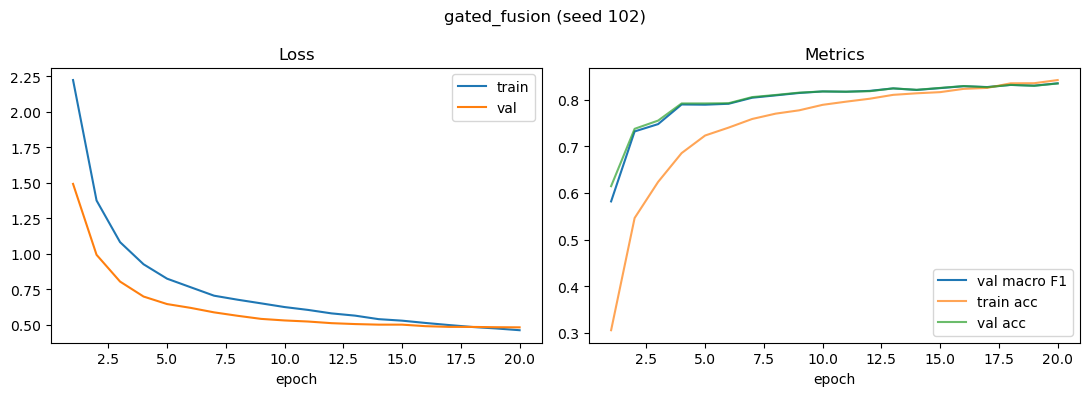

[gated_fusion] Saved per-seed summary: /home/sandy/Document/FusionStyle/results/multimodal/gated_fusion/all_seeds_summary.csv


,seed,accuracy,macro_precision,macro_recall,macro_f1,loss
0,13,0.835520,0.837057,0.838284,0.835506,0.457545
1,14,0.831483,0.834624,0.834714,0.833191,0.469554
2,16,0.850656,0.852444,0.853041,0.851327,0.444757
3,17,0.848638,0.849157,0.851166,0.849242,0.441839
4,45,0.836024,0.836409,0.839599,0.835814,0.458799
5,48,0.835520,0.836955,0.837738,0.835956,0.468286
6,53,0.857719,0.857541,0.860245,0.857993,0.413771
7,58,0.833502,0.834538,0.835412,0.833572,0.472839
8,72,0.842079,0.842156,0.844283,0.841588,0.431447
9,102,0.843592,0.842856,0.845452,0.843316,0.469050


In [7]:
run_robustness_model('gated_fusion')

###  BLIP (frozen image-text encoder)

In [18]:
run_robustness_model('blip')

/home/sandy/miniconda3/envs/fusionstyle/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BlipModel were not initialized from the model checkpoint at Salesforce/blip-image-captioning-base and are newly initialized: ['logit_scale', 'text_model.embeddings.LayerNorm.bias', 'text_model.embeddings.LayerNorm.weight', 'text_model.embeddings.position_embeddings.weight', 'text_model.embeddings.word_embeddings.weight', 'text_model.encoder.layer.0.attention.output.LayerNorm.bias', 'text_model.encoder.layer.0.attention.output.LayerNorm.weight', 'text_model.encoder.layer.0.attention.output.dense.bias', 'text_model.encoder.layer.0.attention.output.dense.weight', 'text_model.encoder.layer.0.attention.self.key.bias', 'text_model.encoder.layer.0.attention.self.key.weig

[blip] Experiment 1/10 | split seed = 13
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.4201 acc 0.2511 | val loss 1.9194 acc 0.5802 macroF1 0.5435
  Epoch 02 | train loss 1.7150 acc 0.4553 | val loss 1.2725 acc 0.6872 macroF1 0.6805
  Epoch 03 | train loss 1.3261 acc 0.5642 | val loss 0.9832 acc 0.7392 macroF1 0.7373


KeyboardInterrupt: 

### ViLBERT-family / ViLT (frozen backbone)

In [9]:
run_robustness_model('vilbert')

/home/sandy/miniconda3/envs/fusionstyle/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[vilbert] Experiment 1/10 | split seed = 13
  Split sizes: train=9248, val=1982, test=1982


RuntimeError: The size of tensor a (127) must match the size of tensor b (40) at non-singleton dimension 1

## 9. Aggregation summary (all models)

In [ ]:
metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]
all_agg: List[pd.DataFrame] = []
all_pc: List[pd.DataFrame] = []

for model_key in MODEL_KEYS:
    agg_df, pc_df = aggregate_model_results(model_key)
    if len(agg_df):
        all_agg.append(agg_df)
        print("\n" + "=" * 80)
        print(f"AGGREGATION SUMMARY — {model_key} ({len(SEEDS)} seeds)")
        print("=" * 80)
        show_cols = ["model", "metric", "mean", "std", "min", "max", "ci_95_lower", "ci_95_upper", "n"]
        print(agg_df[show_cols].to_string(index=False))
    if len(pc_df):
        all_pc.append(pc_df)
        print("\n" + "=" * 50)
        print(f"PER-CLASS PERFORMANCE SUMMARY — {model_key} ({len(SEEDS)} seeds)")
        print("=" * 50)
        print(pc_df[["Style", "F1_Mean", "F1_Std", "F1_CV%"]].to_string(index=False))

if all_agg:
    cross = pd.concat(all_agg, ignore_index=True)
    cross_path = RESULTS_ROOT / "cross_model_aggregation_summary.csv"
    cross.to_csv(cross_path, index=False, encoding="utf-8")
    print("\n" + "=" * 80)
    print("CROSS-MODEL AGGREGATION SUMMARY (macro_f1)")
    print("=" * 80)
    macro = cross[cross["metric"] == "macro_f1"][["model", "mean", "std", "ci_95_lower", "ci_95_upper", "n"]]
    print(macro.sort_values("mean", ascending=False).to_string(index=False))
    print("Saved:", cross_path)
else:
    print("No aggregation results yet. Run model sections above first.")
